In [1]:
!pip install datasets transformers sacrebleu scikit-learn -q


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
!pip install nltk


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_dataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [4]:
# STEP 2: Load dataset WMT14 (German-English)
dataset = load_dataset("wmt14", "de-en", split='train[:1%]')
de_texts = [item['translation']['de'] for item in dataset]
en_texts = [item['translation']['en'] for item in dataset]

# (Optional) Print sample
for i in range(3):
    print(f"DE: {de_texts[i]}\nEN: {en_texts[i]}\n")

DE: Wiederaufnahme der Sitzungsperiode
EN: Resumption of the session

DE: Ich erkläre die am Freitag, dem 17. Dezember unterbrochene Sitzungsperiode des Europäischen Parlaments für wiederaufgenommen, wünsche Ihnen nochmals alles Gute zum Jahreswechsel und hoffe, daß Sie schöne Ferien hatten.
EN: I declare resumed the session of the European Parliament adjourned on Friday 17 December 1999, and I would like once again to wish you a happy new year in the hope that you enjoyed a pleasant festive period.

DE: Wie Sie feststellen konnten, ist der gefürchtete "Millenium-Bug " nicht eingetreten. Doch sind Bürger einiger unserer Mitgliedstaaten Opfer von schrecklichen Naturkatastrophen geworden.
EN: Although, as you will have seen, the dreaded 'millennium bug' failed to materialise, still the people in a number of countries suffered a series of natural disasters that truly were dreadful.



In [5]:
# STEP 3: Preprocessing dan Tokenisasi
num_samples = 10000
de_texts = de_texts[:num_samples]
en_texts = en_texts[:num_samples]

# Tambahkan token start/end
en_texts = ['<start> ' + text + ' <end>' for text in en_texts]

# Tokenizer
de_tokenizer = Tokenizer(filters='', lower=True)
en_tokenizer = Tokenizer(filters='', lower=True)

de_tokenizer.fit_on_texts(de_texts)
en_tokenizer.fit_on_texts(en_texts)

de_seq = de_tokenizer.texts_to_sequences(de_texts)
en_seq = en_tokenizer.texts_to_sequences(en_texts)

# Padding
max_len_de = max([len(x) for x in de_seq])
max_len_en = max([len(x) for x in en_seq])
de_pad = pad_sequences(de_seq, maxlen=max_len_de, padding='post')
en_pad = pad_sequences(en_seq, maxlen=max_len_en, padding='post')

# Vocabulary Size
de_vocab = len(de_tokenizer.word_index) + 1
en_vocab = len(en_tokenizer.word_index) + 1


In [6]:
# STEP 4: Siapkan input & output (Decoder Input dan Target)
decoder_input_data = en_pad[:, :-1]
decoder_target_data = en_pad[:, 1:]
encoder_input_data = de_pad


In [7]:
# STEP 5: Bangun model Encoder-Decoder LSTM (Hyperparameter tuning bisa dimodifikasi di sini)
embedding_dim = 256
lstm_units = 512
dropout_rate = 0.3

# Encoder
encoder_inputs = tf.keras.Input(shape=(max_len_de,))
enc_emb = tf.keras.layers.Embedding(de_vocab, embedding_dim)(encoder_inputs)
enc_lstm, state_h, state_c = tf.keras.layers.LSTM(lstm_units, return_state=True, dropout=dropout_rate)(enc_emb)

# Decoder
decoder_inputs = tf.keras.Input(shape=(max_len_en - 1,))
dec_emb = tf.keras.layers.Embedding(en_vocab, embedding_dim)(decoder_inputs)
decoder_lstm = tf.keras.layers.LSTM(lstm_units, return_sequences=True, dropout=dropout_rate)
decoder_outputs = decoder_lstm(dec_emb, initial_state=[state_h, state_c])
decoder_dense = tf.keras.layers.Dense(en_vocab, activation='softmax')
output = decoder_dense(decoder_outputs)

# Model
model = tf.keras.Model([encoder_inputs, decoder_inputs], output)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 154)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 164)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 154, 256)  │  6,794,496 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 164, 256)  │  4,505,600 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 512),     │  1,574,912 │ embedding[0][0]   │
│                     │ (None, 512),      │            │                   │
│                     │ (None, 512)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 164, 512)  │  1,574,912 │ embedding_1[0][0… │
│                     │                   │            │ lstm[0][1],       │
│                     │                   │            │ lstm[0][2]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 164,       │  9,028,800 │ lstm_1[0][0]      │
│                     │ 17600)            │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,478,720 (89.56 MB)

 Trainable params: 23,478,720 (89.56 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# STEP 6: Training
BATCH_SIZE = 16
EPOCHS = 5

history = model.fit(
    [encoder_input_data, decoder_input_data],
    decoder_target_data[..., np.newaxis],
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2
)


Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 1102s 2s/step - accuracy: 0.8471 - loss: 1.1939 - val_accuracy: 0.8532 - val_loss: 1.0640
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 1245s 2s/step - accuracy: 0.8584 - loss: 0.9899 - val_accuracy: 0.8604 - val_loss: 1.0001
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 3413s 7s/step - accuracy: 0.8669 - loss: 0.9070 - val_accuracy: 0.8656 - val_loss: 0.9636
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 1537s 3s/step - accuracy: 0.8727 - loss: 0.8447 - val_accuracy: 0.8670 - val_loss: 0.9501
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 1110s 2s/step - accuracy: 0.8737 - loss: 0.8078 - val_accuracy: 0.8682 - val_loss: 0.9443


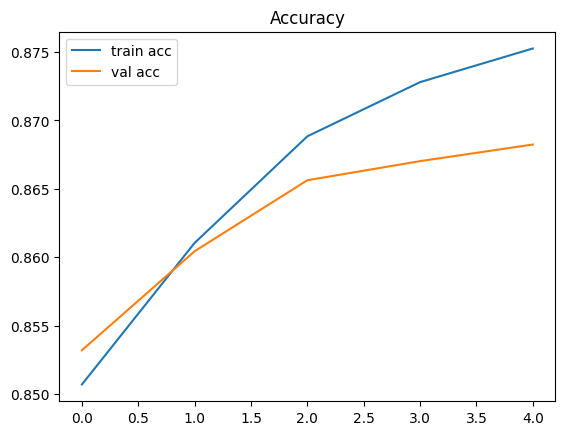

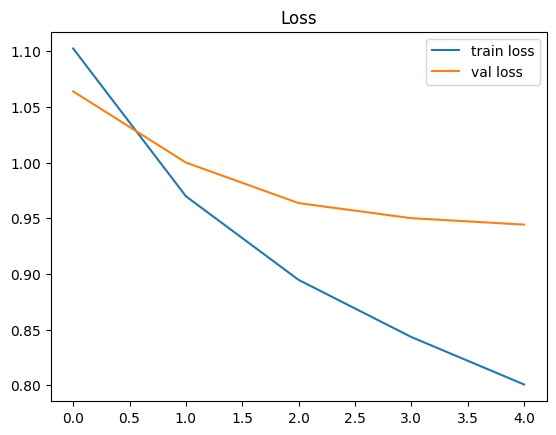

In [10]:
# STEP 7: Visualisasi Loss dan Akurasi
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title("Accuracy")
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title("Loss")
plt.legend()
plt.show()


In [11]:
# STEP 8: Evaluasi Model - Matriks Evaluasi
from sklearn.metrics import classification_report, confusion_matrix

# Fungsi untuk mendekode sequence ke teks
def decode_sequence(input_seq):
    states_value = encoder_model.predict(input_seq)
    
    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = en_tokenizer.word_index['<start>']
    
    stop_condition = False
    decoded_sentence = ''
    
    while not stop_condition:
        output_tokens, h, c = decoder_model.predict([target_seq] + states_value)
        
        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        sampled_word = en_tokenizer.index_word.get(sampled_token_index, '')
        
        decoded_sentence += ' ' + sampled_word
        
        if (sampled_word == '<end>' or len(decoded_sentence.split()) > max_len_en):
            stop_condition = True
        
        target_seq = np.zeros((1, 1))
        target_seq[0, 0] = sampled_token_index
        
        states_value = [h, c]
        
    return decoded_sentence


In [12]:
# Buat model encoder dan decoder inference untuk prediksi
# Encoder inference
encoder_model = tf.keras.Model(encoder_inputs, [state_h, state_c])

# Decoder inference
decoder_state_input_h = tf.keras.Input(shape=(lstm_units,))
decoder_state_input_c = tf.keras.Input(shape=(lstm_units,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

decoder_outputs_inf = decoder_lstm(dec_emb, initial_state=decoder_states_inputs)
decoder_outputs_inf = decoder_dense(decoder_outputs_inf)
decoder_model = tf.keras.Model(
    [decoder_inputs] + decoder_states_inputs,
    [decoder_outputs_inf] + decoder_states_inputs
)

In [13]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

smoothie = SmoothingFunction().method4

# Ambil 100 sampel untuk evaluasi
num_eval = 100
preds = []
refs = []

for i in range(num_eval):
    input_seq = encoder_input_data[i:i+1]
    decoded = decode_sequence(input_seq)
    ref = en_texts[i].replace('<start> ', '').replace(' <end>', '')
    
    preds.append(decoded.strip())
    refs.append(ref.strip())

    print(f"[{i+1}]")
    print("REF :", ref)
    print("PRED:", decoded)
    print()

# BLEU Score Evaluasi
bleu_scores = [sentence_bleu([ref.split()], pred.split(), smoothing_function=smoothie) for ref, pred in zip(refs, preds)]
avg_bleu = np.mean(bleu_scores)
print(f"Rata-rata BLEU Score: {avg_bleu:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 558ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━

In [15]:
from sklearn.metrics import precision_recall_fscore_support

true_tokens = []
pred_tokens = []

for ref, pred in zip(refs, preds):
    ref_tokens = ref.split()
    pred_tokens_sample = pred.split()

    # Sesuaikan panjang
    min_len = min(len(ref_tokens), len(pred_tokens_sample))
    true_tokens.extend(ref_tokens[:min_len])
    pred_tokens.extend(pred_tokens_sample[:min_len])

# Hitung metrik token-level
precision, recall, f1, _ = precision_recall_fscore_support(true_tokens, pred_tokens, average='micro')
accuracy = accuracy_score(true_tokens, pred_tokens)

print(f"Akurasi Token-Level : {accuracy:.4f}")
print(f"Presisi Token-Level : {precision:.4f}")
print(f"Recall Token-Level  : {recall:.4f}")
print(f"F1-Score Token-Level: {f1:.4f}")


Akurasi Token-Level : 0.0172
Presisi Token-Level : 0.0172
Recall Token-Level  : 0.0172
F1-Score Token-Level: 0.0172


🔍 PENYEBAB UMUM
1. Mode Evaluasi vs Training Berbeda
Saat training: model dilatih dengan teacher forcing (decoder dapat input ground truth).
Saat inference: model menghasilkan token satu per satu, hasil sebelumnya jadi input berikutnya → lebih rentan terhadap error propagation.
Jadi meski training accuracy tinggi, inference token-by-token bisa menurun drastis.

2. Evaluasi Token-Level Terlalu Ketat
Dalam accuracy_score(true_tokens, pred_tokens), semua token harus sama persis urutannya.
Bahkan kesalahan satu token saja akan menurunkan akurasi.
Jika prediksi bergeser atau beda sedikit, skornya langsung turun drastis.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━

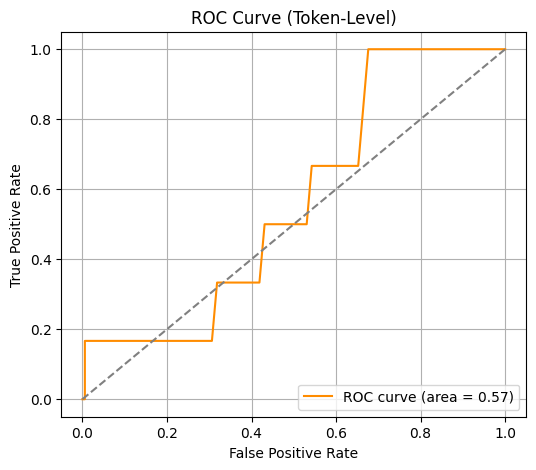

In [17]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Binarisasi label: token benar = 1, salah = 0
y_true_bin = []
y_score_bin = []

for i in range(20):  # Ambil 20 sampel saja karena proses ini berat
    input_seq = encoder_input_data[i:i+1]
    decoded_tokens = []
    decoded_probs = []

    states_value = encoder_model.predict(input_seq)
    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = en_tokenizer.word_index['<start>']
    
    stop_condition = False
    while not stop_condition:
        output_tokens, h, c = decoder_model.predict([target_seq] + states_value)
        probs = output_tokens[0, -1, :]  # Probabilitas softmax
        sampled_token_index = np.argmax(probs)
        sampled_word = en_tokenizer.index_word.get(sampled_token_index, '')

        decoded_tokens.append(sampled_token_index)
        decoded_probs.append(probs[sampled_token_index])

        if sampled_word == '<end>' or len(decoded_tokens) >= max_len_en:
            stop_condition = True
        target_seq[0, 0] = sampled_token_index
        states_value = [h, c]

    # Bandingkan dengan ground truth
    true_seq = en_pad[i, 1:len(decoded_tokens)+1]  # Potong sesuai prediksi
    for true_id, pred_id, prob in zip(true_seq, decoded_tokens, decoded_probs):
        y_true_bin.append(1 if pred_id == true_id else 0)
        y_score_bin.append(prob)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_true_bin, y_score_bin)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Token-Level)')
plt.legend(loc="lower right")
plt.grid()
plt.show()
